# 02 — Cash and liquidity

**Pregunta humana:** ¿Qué niveles de caja podemos afirmar anualmente y qué parte todavía es solo flujo/órbita de gobernanza?

Este reporte todavía trabaja **anual**, para poder compararlo con overview, income y deuda.  
Más adelante hacemos la versión mensual.

Reglas de interpretación:

- **Caja validada** es stock: saldo de cierre confiable.
- **Box / governance flow bridge** es flujo: ingresos, salidas, retiros, funding y neto observado por órbita.
- Si no hay `validated_cash_close` o métrica frontend-safe, la caja queda `s/d`.
- `Box` no se interpreta automáticamente como caja física.
- `Household` es un scope real del long ledger: casa/hogar de Matías y hermanos.
- `Family Business` y `Property Management` son scopes/órbitas diferentes y no deben mezclarse silenciosamente.


In [41]:

from pathlib import Path
import sys
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 240)
pd.set_option("display.width", 280)

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd, *cwd.parents]:
    if (p / "Makefile").exists() and (p / "accounting").is_dir():
        repo_root = p
        break
if repo_root is None:
    raise FileNotFoundError("Could not find repo root. Run from inside accounting-backend.")

reports_dir = repo_root / "accounting" / "notebooks" / "accounting_reports"
if str(reports_dir) not in sys.path:
    sys.path.insert(0, str(reports_dir))

from _shared import *

repo_root = find_repo_root(repo_root)
pack_dir = professional_pack_dir(repo_root)

artifact_inventory = inspect_artifacts(repo_root)
metrics = load_annual_dashboard_metrics(repo_root)
annual_qa = load_annual_dashboard_qa(repo_root)
debt_status = load_debt_status_reconciliation(repo_root)

years = available_years(metrics)
currencies = available_currencies(metrics)
extended_qa = extended_qa_findings(metrics, artifact_inventory, debt_status)

print("repo_root:", repo_root)
print("pack_dir:", pack_dir)
print("years:", years)
print("currencies:", currencies)
print("metric rows:", len(metrics))


repo_root: /home/matias/repos/accounting-backend
pack_dir: /home/matias/repos/accounting-backend/out/professional_pack/latest
years: ['2022', '2023', '2024', '2025', '2026']
currencies: ['ARS', 'N/A', 'USD']
metric rows: 345


In [22]:

# ---------------------------------------------------------------------------
# Cash/liquidity report local helpers
# ---------------------------------------------------------------------------

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def read_optional_csv_path(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def normalize_report_year(s):
    return (
        pd.Series(s)
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.slice(0, 4)
    )


def load_monthly_flow_semantic(repo_root):
    path = repo_root / "out" / "run" / "accounting" / "latest" / "monthly_flow_semantic_split.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def load_monthly_cash_close(repo_root):
    path = repo_root / "out" / "run" / "accounting" / "latest" / "monthly_cash_close.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def prepare_flow_semantic(flow):
    """
    Normalize monthly_flow_semantic_split for annual report-layer audit.

    This does not infer accounting truth. It only standardizes existing semantic
    artifact columns so we can inspect annual flows by Box / actor / channel.
    """
    if flow is None or flow.empty:
        return pd.DataFrame()

    x = flow.copy()
    x.columns = [str(c).strip() for c in x.columns]

    period_col = first_existing_col(x, ["period", "month", "Month", "fecha", "Fecha", "date", "Date"])
    currency_col = first_existing_col(x, ["Currency", "currency", "Moneda"])
    box_col = first_existing_col(x, ["Box", "box", "governance_box", "ledger_scope", "scope"])
    bucket_col = first_existing_col(x, ["semantic_bucket", "bucket", "semantic_class", "category"])
    subbucket_col = first_existing_col(x, ["semantic_subbucket", "subbucket", "semantic_detail", "subcategory"])
    cash_path_col = first_existing_col(x, ["cash_path", "channel", "flow_type", "Tipo", "tipo"])
    payer_col = first_existing_col(x, ["payer", "Payer", "from_actor", "de", "pagador"])
    receiver_col = first_existing_col(x, ["receiver", "Receiver", "to_actor", "a", "receptor"])
    actor_col = first_existing_col(x, ["actor", "Actor", "BoxParty", "party"])
    counterparty_col = first_existing_col(x, ["counterparty", "Counterparty"])

    if period_col is None:
        x["year"] = ""
        x["period_norm"] = ""
    else:
        x["period_norm"] = x[period_col].astype(str)
        x["year"] = normalize_report_year(x[period_col])

    x["Currency_norm"] = x[currency_col].astype(str).str.strip() if currency_col else "N/A"
    x["Box_norm"] = x[box_col].astype(str).str.strip() if box_col else "N/A"
    x["semantic_bucket_norm"] = x[bucket_col].astype(str).str.strip() if bucket_col else "unknown"
    x["semantic_subbucket_norm"] = x[subbucket_col].astype(str).str.strip() if subbucket_col else ""
    x["cash_path_norm"] = x[cash_path_col].astype(str).str.strip() if cash_path_col else ""
    x["payer_norm"] = x[payer_col].astype(str).str.strip() if payer_col else ""
    x["receiver_norm"] = x[receiver_col].astype(str).str.strip() if receiver_col else ""
    x["actor_norm"] = x[actor_col].astype(str).str.strip() if actor_col else ""
    x["counterparty_norm"] = x[counterparty_col].astype(str).str.strip() if counterparty_col else ""

    amount_in_col = first_existing_col(x, ["amount_in", "in_amount", "inflow", "value_in"])
    amount_out_col = first_existing_col(x, ["amount_out", "out_amount", "outflow", "value_out"])
    net_col = first_existing_col(x, ["net_amount", "signed_amount", "amount_signed", "value", "amount", "Amount", "monto", "Monto"])

    if amount_in_col:
        x["amount_in_norm"] = pd.to_numeric(x[amount_in_col], errors="coerce").fillna(0.0)
    else:
        x["amount_in_norm"] = np.nan

    if amount_out_col:
        x["amount_out_norm"] = pd.to_numeric(x[amount_out_col], errors="coerce").fillna(0.0)
    else:
        x["amount_out_norm"] = np.nan

    if net_col:
        raw_net = pd.to_numeric(x[net_col], errors="coerce")
    else:
        raw_net = pd.Series(np.nan, index=x.index)

    # If explicit in/out exist, use them. Otherwise derive in/out from signed net.
    if amount_in_col and amount_out_col:
        x["net_amount_norm"] = x["amount_in_norm"] - x["amount_out_norm"]
    else:
        x["net_amount_norm"] = raw_net.fillna(0.0)
        x["amount_in_norm"] = x["net_amount_norm"].clip(lower=0)
        x["amount_out_norm"] = (-x["net_amount_norm"].clip(upper=0))

    x["amount_abs_norm"] = x["amount_in_norm"].abs() + x["amount_out_norm"].abs()

    return x


def annual_flow_scope_summary(flow_norm, years=None):
    """
    Fine-grained annual summary by Box/actor/counterparty/bucket.
    This is a semantic flow audit, not validated cash balance.
    """
    if flow_norm is None or flow_norm.empty:
        return pd.DataFrame()

    x = flow_norm.copy()
    if years is not None:
        x = x[x["year"].astype(str).isin([str(y) for y in years])]

    group_cols = [
        "year",
        "Currency_norm",
        "Box_norm",
        "semantic_bucket_norm",
        "semantic_subbucket_norm",
        "cash_path_norm",
        "payer_norm",
        "receiver_norm",
        "actor_norm",
        "counterparty_norm",
    ]

    out = (
        x.groupby(group_cols, dropna=False)
        .agg(
            amount_in=("amount_in_norm", "sum"),
            amount_out=("amount_out_norm", "sum"),
            net_amount=("net_amount_norm", "sum"),
            amount_abs=("amount_abs_norm", "sum"),
            n_rows=("net_amount_norm", "size"),
        )
        .reset_index()
        .sort_values(["year", "Currency_norm", "Box_norm", "semantic_bucket_norm", "semantic_subbucket_norm", "amount_abs"], ascending=[True, True, True, True, True, False])
    )

    return out


def annual_box_flow_bridge(flow_norm, years=None):
    """
    Annual bridge by Box.

    Positive columns are magnitudes, not necessarily cash balances:
    - operating_revenue_in: rent/revenue inflows into the reporting scope.
    - property_opex_out: property expenses paid out.
    - family_withdrawal_out: money drained to personal/family spending.
    - funding_contribution_in: contributions/funding.
    - debt_movement_net: net debt-related movement.
    - unknown_net: net unknown/review-required movement.
    - net_flow: existing semantic net in the source artifact.

    This is not a validated cash close.
    """
    if flow_norm is None or flow_norm.empty:
        return pd.DataFrame()

    x = flow_norm.copy()
    if years is not None:
        x = x[x["year"].astype(str).isin([str(y) for y in years])]

    bucket = x["semantic_bucket_norm"].astype(str).str.lower()
    subbucket = x["semantic_subbucket_norm"].astype(str).str.lower()

    x["operating_revenue_in"] = np.where(bucket.eq("operating_revenue"), x["amount_in_norm"], 0.0)
    x["property_opex_out"] = np.where(bucket.eq("property_opex"), x["amount_out_norm"], 0.0)
    x["family_withdrawal_out"] = np.where(bucket.eq("family_withdrawal_candidate"), x["amount_out_norm"], 0.0)
    x["funding_contribution_in"] = np.where(bucket.eq("funding_contribution"), x["amount_in_norm"], 0.0)
    x["debt_movement_net"] = np.where(bucket.str.contains("debt", na=False), x["net_amount_norm"], 0.0)
    x["unknown_net"] = np.where(bucket.str.contains("unknown|review", na=False) | subbucket.str.contains("unknown|review", na=False), x["net_amount_norm"], 0.0)

    out = (
        x.groupby(["year", "Currency_norm", "Box_norm"], dropna=False)
        .agg(
            operating_revenue_in=("operating_revenue_in", "sum"),
            property_opex_out=("property_opex_out", "sum"),
            family_withdrawal_out=("family_withdrawal_out", "sum"),
            funding_contribution_in=("funding_contribution_in", "sum"),
            debt_movement_net=("debt_movement_net", "sum"),
            unknown_net=("unknown_net", "sum"),
            total_amount_in=("amount_in_norm", "sum"),
            total_amount_out=("amount_out_norm", "sum"),
            net_flow=("net_amount_norm", "sum"),
            amount_abs=("amount_abs_norm", "sum"),
            n_rows=("net_amount_norm", "size"),
        )
        .reset_index()
        .sort_values(["year", "Currency_norm", "Box_norm"])
    )

    return out


def annual_box_bridge_wide(bridge, years):
    """
    Human-readable table: one row per Box/Currency/line, years as columns.
    """
    if bridge is None or bridge.empty:
        return pd.DataFrame()

    lines = [
        ("Ingresos operativos / renta", "operating_revenue_in"),
        ("Funding / contribuciones", "funding_contribution_in"),
        ("OPEX propiedad", "property_opex_out"),
        ("Retiros / gasto familiar-personal", "family_withdrawal_out"),
        ("Movimiento neto de deuda", "debt_movement_net"),
        ("Unknown / review-required neto", "unknown_net"),
        ("Total entradas", "total_amount_in"),
        ("Total salidas", "total_amount_out"),
        ("Flujo neto observado", "net_flow"),
    ]

    rows = []
    for _, r in bridge.iterrows():
        for label, col in lines:
            rows.append({
                "Box": r["Box_norm"],
                "Currency": r["Currency_norm"],
                "line": label,
                "year": str(r["year"]),
                "value": r.get(col, np.nan),
            })

    long = pd.DataFrame(rows)
    wide = (
        long.pivot_table(
            index=["Box", "Currency", "line"],
            columns="year",
            values="value",
            aggfunc="sum",
            dropna=False,
        )
        .reset_index()
    )

    for y in years:
        if str(y) not in wide.columns:
            wide[str(y)] = np.nan

    order = {name: i for i, (name, _) in enumerate(lines)}
    wide["line_order"] = wide["line"].map(order)
    wide = wide.sort_values(["Box", "Currency", "line_order"]).drop(columns=["line_order"])

    return wide[["Box", "Currency", "line", *[str(y) for y in years if str(y) in wide.columns]]]


def validated_cash_annual_from_cash_close(cash_close, years=None):
    """
    Best-effort annual close table from monthly_cash_close if available.

    This only reports what the artifact explicitly says. If the artifact is absent
    or lacks a trustworthy close/value column, returns an empty frame.
    """
    if cash_close is None or cash_close.empty:
        return pd.DataFrame()

    x = cash_close.copy()
    x.columns = [str(c).strip() for c in x.columns]

    period_col = first_existing_col(x, ["period", "month", "Month", "fecha", "Fecha", "date", "Date"])
    currency_col = first_existing_col(x, ["Currency", "currency", "Moneda"])
    box_col = first_existing_col(x, ["Box", "box", "account", "Account", "cash_account", "governance_box"])
    value_col = first_existing_col(x, ["value", "close_amount", "closing_balance", "cash_close", "balance", "amount", "Monto"])

    if period_col is None or value_col is None:
        return pd.DataFrame()

    x["year"] = normalize_report_year(x[period_col])
    x["period_sort"] = x[period_col].astype(str)
    x["Currency"] = x[currency_col].astype(str).str.strip() if currency_col else "N/A"
    x["Box"] = x[box_col].astype(str).str.strip() if box_col else "N/A"
    x["value"] = pd.to_numeric(x[value_col], errors="coerce")

    # Respect explicit frontend-safe / validated columns if they exist.
    safe_col = first_existing_col(x, ["frontend_safe", "is_frontend_safe", "validated", "is_validated"])
    if safe_col is not None:
        safe = x[safe_col].astype(str).str.lower().isin(["true", "1", "yes", "y", "validated", "frontend_safe"])
        x = x[safe].copy()

    if years is not None:
        x = x[x["year"].isin([str(y) for y in years])]

    if x.empty:
        return pd.DataFrame()

    # Last observed close in each year.
    x = x.sort_values(["year", "Currency", "Box", "period_sort"])
    out = x.groupby(["year", "Currency", "Box"], dropna=False).tail(1)

    wide = (
        out.pivot_table(index=["Box", "Currency"], columns="year", values="value", aggfunc="last")
        .reset_index()
    )
    for y in years or []:
        if str(y) not in wide.columns:
            wide[str(y)] = np.nan

    return wide[["Box", "Currency", *[str(y) for y in years if str(y) in wide.columns]]]


def format_display_df(df, years=None):
    out = df.copy()
    if years is None:
        years = [c for c in out.columns if str(c).isdigit()]
    for y in years:
        if y in out.columns:
            out[y] = out[y].apply(lambda v: format_number_es(v) if pd.notna(v) else "s/d")
    return out


def fb_related_mask(flow_norm):
    if flow_norm is None or flow_norm.empty:
        return pd.Series(False, index=pd.RangeIndex(0))
    cols = ["Box_norm", "payer_norm", "receiver_norm", "actor_norm", "counterparty_norm"]
    mask = pd.Series(False, index=flow_norm.index)
    for c in cols:
        if c in flow_norm.columns:
            mask = mask | flow_norm[c].astype(str).str.contains("Family Business|\\bFB\\b", case=False, regex=True, na=False)
    return mask


def mask_reason_fb(row):
    reasons = []
    checks = {
        "box_match": "Box_norm",
        "payer_match": "payer_norm",
        "receiver_match": "receiver_norm",
        "actor_match": "actor_norm",
        "counterparty_match": "counterparty_norm",
    }
    for reason, col in checks.items():
        if col in row.index and pd.notna(row[col]) and re.search(r"Family Business|\bFB\b", str(row[col]), flags=re.I):
            reasons.append(reason)
    return ",".join(reasons)


## 1. Cash QA / readiness

Este bloque decide qué podemos decir sobre caja.

La postura conservadora:

```text
Si no hay cash frontend-safe, no hay nivel de caja auditable.
```

Eso no impide analizar flujos por Box, pero esos flujos no son caja validada.


In [23]:
cash_qa = extended_qa[extended_qa["area"].isin(["cash", "metrics", "currency"])].copy()
display(short_status_table(cash_qa))
export_table(cash_qa, repo_root, "cash_liquidity_extended_qa.csv")

cash_metrics = metrics[
    metrics["metric_id"].astype(str).str.contains(r"BS\.CASH|DQ\.CASH", regex=True, na=False)
].copy()

display(
    cash_metrics[
        [c for c in [
            "metric_id", "dashboard_section", "Currency", "period",
            "dimension_name", "dimension_value", "value", "value_status",
            "source_table", "caveat"
        ] if c in cash_metrics.columns]
    ].sort_values(["metric_id", "Currency", "period", "dimension_name", "dimension_value"])
)

export_table(cash_metrics, repo_root, "cash_metrics_inventory.csv")


,severity,area,check,n,detail
3,ok,cash,cash_frontend_safe_available,5,5 available cash rows
2,ok,currency,no_cross_currency_totals,0,No suspicious cross-currency Currency labels f...
1,ok,metrics,available_metric_has_value,0,No available metrics with NaN values
5,warning,metrics,unavailable_visible,7,7 unavailable/blocked rows should be surfaced ...


,metric_id,dashboard_section,Currency,period,dimension_name,dimension_value,value,value_status,source_table,caveat
209,BS.CASH.CLOSE.BOX,3. Cash and liquidity,N/A,nan,,,NaN,unavailable,monthly_cash_close.csv,No frontend-safe cash rows exist; no fallback ...
343,BS.CASH.FB,7. Legacy reconciliation,N/A,nan,,,NaN,not_applicable,metric_contract_frontier.csv,Legacy/reconciliation only unless rebuilt from...
344,BS.CASH.PM,7. Legacy reconciliation,N/A,nan,,,NaN,not_applicable,metric_contract_frontier.csv,Legacy/reconciliation only unless rebuilt from...
208,BS.CASH.TOTAL,3. Cash and liquidity,N/A,nan,,,NaN,unavailable,monthly_cash_close.csv,No frontend-safe cash rows exist; no fallback ...
210,DQ.CASH.FRONTEND_SAFE,3. Cash and liquidity,N/A,2022,,,0.0,available,monthly_cash_close.csv,
211,DQ.CASH.FRONTEND_SAFE,3. Cash and liquidity,N/A,2023,,,0.0,available,monthly_cash_close.csv,
212,DQ.CASH.FRONTEND_SAFE,3. Cash and liquidity,N/A,2024,,,0.0,available,monthly_cash_close.csv,
213,DQ.CASH.FRONTEND_SAFE,3. Cash and liquidity,N/A,2025,,,0.0,available,monthly_cash_close.csv,
214,DQ.CASH.FRONTEND_SAFE,3. Cash and liquidity,N/A,2026,,,0.0,available,monthly_cash_close.csv,


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_metrics_inventory.csv')

## 2. Annual validated cash levels

Primero mostramos lo más estricto: caja validada anual.

Si no existe, el resultado correcto es `s/d`, no cero.


In [24]:
cash_level_specs = [
    spec("Cash", "Caja validada", "Caja validada total", "BS.CASH.TOTAL", 100,
         professional_comment="Saldo de caja solo si existe fuente frontend-safe. Si no existe, s/d."),
    spec("Cash", "Caja validada", "Caja validada por Box/cuenta", "BS.CASH.CLOSE.BOX", 120,
         append_dimension=True,
         professional_comment="Saldo de caja por Box/cuenta solo si el backend lo considera frontend-safe."),
]

cash_levels_from_metrics = build_statement_table(
    metrics,
    cash_level_specs,
    years,
    include_debug_cols=True,
    drop_all_empty_years=False,
)

display_statement(
    cash_levels_from_metrics,
    "Niveles anuales de caja validada — desde annual metrics",
    "Stock anual frontend-safe si existe. Si aparece unavailable/s/d, no usar flow bridge como sustituto.",
    debug=True,
)
export_table(cash_levels_from_metrics, repo_root, "cash_validated_levels_from_metrics.csv")


## Niveles anuales de caja validada — desde annual metrics

Stock anual frontend-safe si existe. Si aparece unavailable/s/d, no usar flow bridge como sustituto.

section,line,metric_id,dimension_name,dimension_value,Currency,2022,2023,2024,2025,2026,value_status,professional_comment,caveat,source_table,format_hint
Caja validada,Caja validada total,BS.CASH.TOTAL,,,N/A,s/d,s/d,s/d,s/d,s/d,unavailable,"Saldo de caja solo si existe fuente frontend-safe. Si no existe, s/d.",No frontend-safe cash rows exist; no fallback used.,monthly_cash_close.csv,number
Caja validada,Caja validada por Box/cuenta,BS.CASH.CLOSE.BOX,,,N/A,s/d,s/d,s/d,s/d,s/d,unavailable,Saldo de caja por Box/cuenta solo si el backend lo considera frontend-safe.,No frontend-safe cash rows exist; no fallback used.,monthly_cash_close.csv,number


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_validated_levels_from_metrics.csv')

## 3. Optional monthly_cash_close annual close

Si existe `monthly_cash_close.csv`, esta celda toma el último close explícito de cada año.

Importante: si el artifact no marca validación/frontend-safe, esto es solo una lectura auxiliar y debe quedar con caveat.


In [25]:
monthly_cash_close = load_monthly_cash_close(repo_root)
print("monthly_cash_close rows:", len(monthly_cash_close))
if not monthly_cash_close.empty:
    display(monthly_cash_close.head(50))
    annual_cash_close = validated_cash_annual_from_cash_close(monthly_cash_close, years)
else:
    annual_cash_close = pd.DataFrame()

if annual_cash_close.empty:
    annual_cash_close_display = pd.DataFrame([{
        "Box": "s/d",
        "Currency": "s/d",
        **{y: "s/d" for y in years},
        "caveat": "No monthly_cash_close frontend-safe disponible o no se pudo identificar close/value confiable.",
    }])
    display(annual_cash_close_display)
else:
    display(format_display_df(annual_cash_close, years))
    export_table(annual_cash_close, repo_root, "cash_annual_close_from_monthly_cash_close.csv")


monthly_cash_close rows: 2208


,period,period_end,as_of_date,Box,party,account_id,account_name,Currency,close_amount,source_table,source_date,source_type,source_reference,validation_status,validated_by,position_type,cash_suitability,is_frontend_safe,caveat,notes,n_source_rows,calculation_rule
0,2022-01,2022-01-31,2022-01-31,Family Business,Alejandro,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
1,2022-01,2022-01-31,2022-01-31,Family Business,Costos,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
2,2022-01,2022-01-31,2022-01-31,Family Business,FB,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
3,2022-01,2022-01-31,2022-01-31,Family Business,Gasto,NaN,NaN,ARS,144000.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
4,2022-01,2022-01-31,2022-01-31,Family Business,Hector,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
5,2022-01,2022-01-31,2022-01-31,Family Business,Impuestos,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
6,2022-01,2022-01-31,2022-01-31,Family Business,Inq,NaN,NaN,ARS,-144000.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
7,2022-01,2022-01-31,2022-01-31,Family Business,MI,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
8,2022-01,2022-01-31,2022-01-31,Family Business,Primos,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...
9,2022-01,2022-01-31,2022-01-31,Family Business,Servicios,NaN,NaN,ARS,0.0,daily_cash_position.csv,2022-01-31,internal_party_balance,NaN,not_validated_for_frontend_cash,NaN,internal_balance,internal_only,False,Party-level daily cash position is an internal...,NaN,1,last observed daily_cash_position.balance by m...


,Box,Currency,2022,2023,2024,2025,2026,caveat
0,s/d,s/d,s/d,s/d,s/d,s/d,s/d,No monthly_cash_close frontend-safe disponible...


## 4. Annual Box / governance flow bridge

Este es el corazón del reporte.

No responde “cuánta caja había”.  
Responde:

```text
¿Qué flujos entraron y salieron por cada órbita del ledger?
```

Esto permite ver cosas como:

- FB cobra renta;
- FB retira/gasta casi toda la renta;
- PM paga OPEX;
- Household existe como scope separado;
- algunas contribuciones entran a un Box aunque el payer/receiver digan otra cosa.

Este bridge es **flujo semántico anual**, no balance de caja.


In [26]:
monthly_flow = load_monthly_flow_semantic(repo_root)
print("monthly_flow rows:", len(monthly_flow))
if not monthly_flow.empty:
    display(pd.DataFrame({"column": monthly_flow.columns}))
    display(monthly_flow.head(30))

flow_norm = prepare_flow_semantic(monthly_flow)
print("flow_norm rows:", len(flow_norm))
if not flow_norm.empty:
    display(flow_norm.head(30))

annual_scope = annual_flow_scope_summary(flow_norm, years)
annual_bridge = annual_box_flow_bridge(flow_norm, years)
annual_bridge_wide = annual_box_bridge_wide(annual_bridge, years)

display(format_display_df(annual_bridge_wide, years))
export_table(annual_scope, repo_root, "cash_annual_flow_scope_summary.csv")
export_table(annual_bridge, repo_root, "cash_annual_box_flow_bridge_long.csv")
export_table(annual_bridge_wide, repo_root, "cash_annual_box_flow_bridge_wide.csv")


monthly_flow rows: 787


,column
0,period
1,period_end
2,Currency
3,Box
4,Lugar
5,actor
6,counterparty
7,payer
8,receiver
9,channel


,period,period_end,Currency,Box,Lugar,actor,counterparty,payer,receiver,channel,cash_path,semantic_bucket,semantic_subbucket,amount_in,amount_out,net_amount,amount_abs,n_tx,classification_status,classification_confidence,review_required,source_table,source_tx_ids_sample,rule_ids,notes
0,2022-01,2022-01-31,ARS,Family Business,CABA,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,60000.0,0.0,60000.0,60000.0,1,classified,high,False,ledger_canonical.csv,45fbb172b72d62e3,R001_rent_collections,NaN
1,2022-01,2022-01-31,ARS,Family Business,Tigre 01,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,16000.0,0.0,16000.0,16000.0,1,classified,high,False,ledger_canonical.csv,9619ce2f379c3140,R001_rent_collections,NaN
2,2022-01,2022-01-31,ARS,Family Business,Tigre 28,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,38000.0,0.0,38000.0,38000.0,1,classified,high,False,ledger_canonical.csv,2b835804fefea925,R001_rent_collections,NaN
3,2022-01,2022-01-31,ARS,Family Business,Tigre 32,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,30000.0,0.0,30000.0,30000.0,1,classified,high,False,ledger_canonical.csv,49f999670d2cffcb,R001_rent_collections,NaN
4,2022-01,2022-01-31,ARS,Family Business,NaN,Family Business,Gasto,FB,Gasto,Family Business,Transfer:Gasto,family_withdrawal_candidate,personal_expense,0.0,144000.0,-144000.0,144000.0,1,classified,medium,False,ledger_canonical.csv,8cc68408863f1946,R011_personal_expense_text,review family/informal withdrawal candidate
5,2022-02,2022-02-28,ARS,Family Business,CABA,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,72000.0,0.0,72000.0,72000.0,1,classified,high,False,ledger_canonical.csv,f93053e4614c9813,R001_rent_collections,NaN
6,2022-02,2022-02-28,ARS,Family Business,Tigre,Family Business,Costos,FB,Costos,Family Business,Pagos:Mantenimiento,property_opex,maintenance,0.0,107500.0,-107500.0,107500.0,1,classified,high,False,ledger_canonical.csv,e64651acf61c7314,R004_property_maintenance,NaN
7,2022-02,2022-02-28,ARS,Family Business,Tigre,Family Business,Impuestos,FB,Impuestos,Family Business,Pagos:Impuestos,property_opex,taxes,0.0,19400.0,-19400.0,19400.0,1,classified,high,False,ledger_canonical.csv,a9df6eafbef77cdf,R002_property_taxes,NaN
8,2022-02,2022-02-28,ARS,Family Business,Tigre 01,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,16000.0,0.0,16000.0,16000.0,1,classified,high,False,ledger_canonical.csv,489572781da0f3af,R001_rent_collections,NaN
9,2022-02,2022-02-28,ARS,Family Business,Tigre 32,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,30000.0,0.0,30000.0,30000.0,1,classified,high,False,ledger_canonical.csv,65f929f1a0ca5583,R001_rent_collections,NaN


flow_norm rows: 787


,period,period_end,Currency,Box,Lugar,actor,counterparty,payer,receiver,channel,cash_path,semantic_bucket,semantic_subbucket,amount_in,amount_out,net_amount,amount_abs,n_tx,classification_status,classification_confidence,review_required,source_table,source_tx_ids_sample,rule_ids,notes,period_norm,year,Currency_norm,Box_norm,semantic_bucket_norm,semantic_subbucket_norm,cash_path_norm,payer_norm,receiver_norm,actor_norm,counterparty_norm,amount_in_norm,amount_out_norm,net_amount_norm,amount_abs_norm
0,2022-01,2022-01-31,ARS,Family Business,CABA,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,60000.0,0.0,60000.0,60000.0,1,classified,high,False,ledger_canonical.csv,45fbb172b72d62e3,R001_rent_collections,NaN,2022-01,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,60000.0,0.0,60000.0,60000.0
1,2022-01,2022-01-31,ARS,Family Business,Tigre 01,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,16000.0,0.0,16000.0,16000.0,1,classified,high,False,ledger_canonical.csv,9619ce2f379c3140,R001_rent_collections,NaN,2022-01,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,16000.0,0.0,16000.0,16000.0
2,2022-01,2022-01-31,ARS,Family Business,Tigre 28,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,38000.0,0.0,38000.0,38000.0,1,classified,high,False,ledger_canonical.csv,2b835804fefea925,R001_rent_collections,NaN,2022-01,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,38000.0,0.0,38000.0,38000.0
3,2022-01,2022-01-31,ARS,Family Business,Tigre 32,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,30000.0,0.0,30000.0,30000.0,1,classified,high,False,ledger_canonical.csv,49f999670d2cffcb,R001_rent_collections,NaN,2022-01,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,30000.0,0.0,30000.0,30000.0
4,2022-01,2022-01-31,ARS,Family Business,NaN,Family Business,Gasto,FB,Gasto,Family Business,Transfer:Gasto,family_withdrawal_candidate,personal_expense,0.0,144000.0,-144000.0,144000.0,1,classified,medium,False,ledger_canonical.csv,8cc68408863f1946,R011_personal_expense_text,review family/informal withdrawal candidate,2022-01,2022,ARS,Family Business,family_withdrawal_candidate,personal_expense,Transfer:Gasto,FB,Gasto,Family Business,Gasto,0.0,144000.0,-144000.0,144000.0
5,2022-02,2022-02-28,ARS,Family Business,CABA,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,72000.0,0.0,72000.0,72000.0,1,classified,high,False,ledger_canonical.csv,f93053e4614c9813,R001_rent_collections,NaN,2022-02,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,72000.0,0.0,72000.0,72000.0
6,2022-02,2022-02-28,ARS,Family Business,Tigre,Family Business,Costos,FB,Costos,Family Business,Pagos:Mantenimiento,property_opex,maintenance,0.0,107500.0,-107500.0,107500.0,1,classified,high,False,ledger_canonical.csv,e64651acf61c7314,R004_property_maintenance,NaN,2022-02,2022,ARS,Family Business,property_opex,maintenance,Pagos:Mantenimiento,FB,Costos,Family Business,Costos,0.0,107500.0,-107500.0,107500.0
7,2022-02,2022-02-28,ARS,Family Business,Tigre,Family Business,Impuestos,FB,Impuestos,Family Business,Pagos:Impuestos,property_opex,taxes,0.0,19400.0,-19400.0,19400.0,1,classified,high,False,ledger_canonical.csv,a9df6eafbef77cdf,R002_property_taxes,NaN,2022-02,2022,ARS,Family Business,property_opex,taxes,Pagos:Impuestos,FB,Impuestos,Family Business,Impuestos,0.0,19400.0,-19400.0,19400.0
8,2022-02,2022-02-28,ARS,Family Business,Tigre 01,Family Business,Inq,Inq,FB,Family Business,Cobros:Renta,operating_revenue,rent,16000.0,0.0,16000.0,16000.0,1,classified,high,False,ledger_canonical.csv,489572781da0f3af,R001_rent_collections,NaN,2022-02,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,16000.0,0.0,16000.0,16000.0
9,2022-02,2022-0

year,Box,Currency,line,2022,2023,2024,2025,2026
2,Family Business,ARS,Ingresos operativos / renta,4.948.804,8.781.302,13.558.336,36.915.422,25.444.000
1,Family Business,ARS,Funding / contribuciones,0,0,0,0,0
4,Family Business,ARS,OPEX propiedad,587.266,192.756,0,2.409.735,426.252
5,Family Business,ARS,Retiros / gasto familiar-personal,4.361.538,8.588.545,13.558.322,32.805.691,23.154.969
3,Family Business,ARS,Movimiento neto de deuda,0,0,0,0,0
8,Family Business,ARS,Unknown / review-required neto,0,0,0,0,0
6,Family Business,ARS,Total entradas,4.948.804,8.781.302,13.558.336,36.915.422,25.444.000
7,Family Business,ARS,Total salidas,4.948.804,8.781.301,13.558.322,35.215.426,23.581.221
0,Family Business,ARS,Flujo neto observado,0,1,14,1.699.996,1.862.779
11,Family Business,USD,Ingresos operativos / renta,s/d,s/d,s/d,s/d,s/d


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_annual_box_flow_bridge_wide.csv')

In [27]:
# ---------------------------------------------------------------------------
# Unknown / review-required rows audit
# ---------------------------------------------------------------------------

def audit_unknown_review_rows(flow_norm, years=("2024", "2026"), currency="ARS", box="Property Management"):
    if flow_norm is None or flow_norm.empty:
        print("flow_norm is empty")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    x = flow_norm.copy()

    bucket = x["semantic_bucket_norm"].astype(str).str.lower()
    subbucket = x["semantic_subbucket_norm"].astype(str).str.lower()
    cash_path = x["cash_path_norm"].astype(str).str.lower()

    unknown_mask = (
        bucket.str.contains("unknown|review|ambiguous|unclassified", regex=True, na=False)
        | subbucket.str.contains("unknown|review|ambiguous|unclassified", regex=True, na=False)
        | cash_path.str.contains("unknown|review|ambiguous|unclassified", regex=True, na=False)
    )

    target = x[
        x["year"].astype(str).isin([str(y) for y in years])
        & x["Currency_norm"].astype(str).eq(currency)
        & x["Box_norm"].astype(str).eq(box)
        & unknown_mask
    ].copy()

    # Useful readable columns, only if present
    preferred_cols = [
        "year",
        "period_norm",
        "Currency_norm",
        "Box_norm",
        "semantic_bucket_norm",
        "semantic_subbucket_norm",
        "cash_path_norm",
        "payer_norm",
        "receiver_norm",
        "actor_norm",
        "counterparty_norm",
        "amount_in_norm",
        "amount_out_norm",
        "net_amount_norm",
        "amount_abs_norm",
    ]

    # Add potentially useful original/source columns if they exist
    source_like_cols = [
        c for c in target.columns
        if any(token in c.lower() for token in [
            "tx", "id", "source", "fecha", "date", "tipo", "detail",
            "descripcion", "description", "concepto", "memo", "nota", "note"
        ])
    ]

    show_cols = []
    for c in preferred_cols + source_like_cols:
        if c in target.columns and c not in show_cols:
            show_cols.append(c)

    detail = target[show_cols].sort_values(
        [c for c in ["year", "period_norm", "semantic_bucket_norm", "semantic_subbucket_norm", "cash_path_norm"] if c in show_cols]
    )

    grouped = (
        target
        .groupby([
            "year",
            "Currency_norm",
            "Box_norm",
            "semantic_bucket_norm",
            "semantic_subbucket_norm",
            "cash_path_norm",
            "payer_norm",
            "receiver_norm",
            "actor_norm",
            "counterparty_norm",
        ], dropna=False)
        .agg(
            amount_in=("amount_in_norm", "sum"),
            amount_out=("amount_out_norm", "sum"),
            net_amount=("net_amount_norm", "sum"),
            amount_abs=("amount_abs_norm", "sum"),
            n_rows=("net_amount_norm", "size"),
        )
        .reset_index()
        .sort_values(["year", "amount_abs"], ascending=[True, False])
    )

    check = (
        target
        .groupby(["year", "Currency_norm", "Box_norm"], dropna=False)
        .agg(
            amount_in=("amount_in_norm", "sum"),
            amount_out=("amount_out_norm", "sum"),
            net_amount=("net_amount_norm", "sum"),
            amount_abs=("amount_abs_norm", "sum"),
            n_rows=("net_amount_norm", "size"),
        )
        .reset_index()
        .sort_values(["year", "Currency_norm", "Box_norm"])
    )

    return detail, grouped, check


unknown_detail, unknown_grouped, unknown_check = audit_unknown_review_rows(
    flow_norm,
    years=("2024", "2026"),
    currency="ARS",
    box="Property Management",
)

display_statement(
    unknown_check.rename(columns={
        "Currency_norm": "Currency",
        "Box_norm": "Box",
    }),
    "Check unknown / review-required — PM ARS",
    "Debe reconciliar contra 2024 = 2.164.500 y 2026 = 410.768 en el Box flow bridge.",
    debug=True,
)

display(unknown_grouped)
display(unknown_detail)

export_table(unknown_check, repo_root, "cash_unknown_review_pm_ars_check.csv")
export_table(unknown_grouped, repo_root, "cash_unknown_review_pm_ars_grouped.csv")
export_table(unknown_detail, repo_root, "cash_unknown_review_pm_ars_detail.csv")

## Check unknown / review-required — PM ARS

Debe reconciliar contra 2024 = 2.164.500 y 2026 = 410.768 en el Box flow bridge.

year,Currency,Box,amount_in,amount_out,net_amount,amount_abs,n_rows


,year,Currency_norm,Box_norm,semantic_bucket_norm,semantic_subbucket_norm,cash_path_norm,payer_norm,receiver_norm,actor_norm,counterparty_norm,amount_in,amount_out,net_amount,amount_abs,n_rows


,year,period_norm,Currency_norm,Box_norm,semantic_bucket_norm,semantic_subbucket_norm,cash_path_norm,payer_norm,receiver_norm,actor_norm,counterparty_norm,amount_in_norm,amount_out_norm,net_amount_norm,amount_abs_norm,n_tx,classification_confidence,source_table,source_tx_ids_sample,rule_ids,notes


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_unknown_review_pm_ars_detail.csv')

In [28]:
# ---------------------------------------------------------------------------
# Reconcile unknown rows against annual_box_flow_bridge
# ---------------------------------------------------------------------------

bridge_unknown = annual_bridge[
    annual_bridge["Box_norm"].astype(str).eq("Property Management")
    & annual_bridge["Currency_norm"].astype(str).eq("ARS")
    & annual_bridge["year"].astype(str).isin(["2024", "2026"])
][
    ["year", "Currency_norm", "Box_norm", "unknown_net"]
].copy()

row_unknown = unknown_check[
    ["year", "Currency_norm", "Box_norm", "net_amount"]
].copy()

recon_unknown = bridge_unknown.merge(
    row_unknown,
    on=["year", "Currency_norm", "Box_norm"],
    how="outer",
)

recon_unknown["residual"] = (
    pd.to_numeric(recon_unknown["unknown_net"], errors="coerce").fillna(0)
    - pd.to_numeric(recon_unknown["net_amount"], errors="coerce").fillna(0)
)

display(recon_unknown)

export_table(recon_unknown, repo_root, "cash_unknown_review_pm_ars_reconciliation.csv")

,year,Currency_norm,Box_norm,unknown_net,net_amount,residual
0,2024,ARS,Property Management,0.0,NaN,0.0
1,2026,ARS,Property Management,0.0,NaN,0.0


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_unknown_review_pm_ars_reconciliation.csv')

In [29]:
# ---------------------------------------------------------------------------
# Reconcile unknown rows against annual_box_flow_bridge
# ---------------------------------------------------------------------------

bridge_unknown = annual_bridge[
    annual_bridge["Box_norm"].astype(str).eq("Property Management")
    & annual_bridge["Currency_norm"].astype(str).eq("ARS")
    & annual_bridge["year"].astype(str).isin(["2024", "2026"])
][
    ["year", "Currency_norm", "Box_norm", "unknown_net"]
].copy()

row_unknown = unknown_check[
    ["year", "Currency_norm", "Box_norm", "net_amount"]
].copy()

recon_unknown = bridge_unknown.merge(
    row_unknown,
    on=["year", "Currency_norm", "Box_norm"],
    how="outer",
)

recon_unknown["residual"] = (
    pd.to_numeric(recon_unknown["unknown_net"], errors="coerce").fillna(0)
    - pd.to_numeric(recon_unknown["net_amount"], errors="coerce").fillna(0)
)

display(recon_unknown)

export_table(recon_unknown, repo_root, "cash_unknown_review_pm_ars_reconciliation.csv")

,year,Currency_norm,Box_norm,unknown_net,net_amount,residual
0,2024,ARS,Property Management,0.0,NaN,0.0
1,2026,ARS,Property Management,0.0,NaN,0.0


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_unknown_review_pm_ars_reconciliation.csv')

In [30]:
# ---------------------------------------------------------------------------
# Discover available level/time-series artifacts
# ---------------------------------------------------------------------------

ts_candidates = {
    "box_balance_m": "out/run/accounting/latest/box_balance_time_long.freq=M.csv",
    "box_flow_balance_m": "out/run/accounting/latest/box_flow_balance_time_long.freq=M.csv",
    "daily_cash_position": "out/run/accounting/latest/daily_cash_position.csv",
    "monthly_cash_close": "out/run/accounting/latest/monthly_cash_close.csv",
    "monthly_debt_position_run": "out/run/accounting/latest/monthly_debt_position.csv",
    "monthly_debt_position_debt": "out/debt_resolution/latest/monthly_debt_position.csv",
    "frontend_metric_series": "out/metrics/latest/frontend_metric_series.csv",
}

ts_inventory_rows = []

for key, rel in ts_candidates.items():
    path = repo_root / rel
    if path.exists():
        df0 = pd.read_csv(path, nrows=5)
        ts_inventory_rows.append({
            "key": key,
            "path": rel,
            "exists": True,
            "sample_rows": len(df0),
            "columns": ", ".join(df0.columns),
        })
    else:
        ts_inventory_rows.append({
            "key": key,
            "path": rel,
            "exists": False,
            "sample_rows": 0,
            "columns": "",
        })

ts_inventory = pd.DataFrame(ts_inventory_rows)
display(ts_inventory)

export_table(ts_inventory, repo_root, "cash_levels_ts_inventory.csv")

,key,path,exists,sample_rows,columns
0,box_balance_m,out/run/accounting/latest/box_balance_time_lon...,True,5,"TimePeriod, TimePeriod_end, Box, Currency, in_..."
1,box_flow_balance_m,out/run/accounting/latest/box_flow_balance_tim...,True,5,"TimePeriod, TimePeriod_end, Box, Currency, Flu..."
2,daily_cash_position,out/run/accounting/latest/daily_cash_position.csv,True,5,"Date, Box, party, Currency, balance, source_le..."
3,monthly_cash_close,out/run/accounting/latest/monthly_cash_close.csv,True,5,"period, period_end, as_of_date, Box, party, ac..."
4,monthly_debt_position_run,out/run/accounting/latest/monthly_debt_positio...,True,5,"period, period_end, as_of_date, debtor, credit..."
5,monthly_debt_position_debt,out/debt_resolution/latest/monthly_debt_positi...,False,0,
6,frontend_metric_series,out/metrics/latest/frontend_metric_series.csv,True,5,"metric_id, period_grain, period, period_end, C..."


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_levels_ts_inventory.csv')

In [31]:
def load_ts_artifact(repo_root, relpath):
    path = repo_root / relpath
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_level_ts(df, artifact_key):
    """
    Normalize level-like time series into:
    date, period, year, Currency, Box, series_name, value, source_artifact

    This is report-layer normalization only.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    x = df.copy()
    x.columns = [str(c).strip() for c in x.columns]

    date_col = first_existing_col(x, [
        "date", "Date", "Fecha", "fecha",
        "period", "Period", "month", "Month"
    ])
    currency_col = first_existing_col(x, ["Currency", "currency", "Moneda"])
    box_col = first_existing_col(x, [
        "Box", "box", "BoxParty", "account", "Account",
        "cash_account", "governance_box", "actor", "party"
    ])
    series_col = first_existing_col(x, [
        "metric_id", "series_name", "metric", "flow_type",
        "balance_type", "name", "variable"
    ])
    value_col = first_existing_col(x, [
        "value", "balance", "close_amount", "closing_balance",
        "amount", "Amount", "net_amount", "saldo", "Saldo", "Monto"
    ])

    if date_col is None or value_col is None:
        print(f"Could not normalize {artifact_key}. Columns:", list(x.columns))
        return pd.DataFrame()

    out = pd.DataFrame()
    out["date_raw"] = x[date_col].astype(str)
    out["date"] = pd.to_datetime(x[date_col], errors="coerce")
    out["period"] = out["date"].dt.to_period("M").astype(str)
    out.loc[out["date"].isna(), "period"] = x[date_col].astype(str).str.slice(0, 7)
    out["year"] = out["period"].astype(str).str.slice(0, 4)

    out["Currency"] = x[currency_col].astype(str).str.strip() if currency_col else "N/A"
    out["Box"] = x[box_col].astype(str).str.strip() if box_col else "N/A"
    out["series_name"] = x[series_col].astype(str).str.strip() if series_col else artifact_key
    out["value"] = pd.to_numeric(x[value_col], errors="coerce")
    out["source_artifact"] = artifact_key

    # Keep useful debug columns
    for c in ["metric_id", "flow_type", "balance_type", "source_table", "value_status", "caveat"]:
        if c in x.columns and c not in out.columns:
            out[c] = x[c]

    return out

In [32]:
level_ts_parts = []

for key, rel in ts_candidates.items():
    df_raw = load_ts_artifact(repo_root, rel)
    df_norm = normalize_level_ts(df_raw, key)
    if not df_norm.empty:
        level_ts_parts.append(df_norm)

level_ts = pd.concat(level_ts_parts, ignore_index=True) if level_ts_parts else pd.DataFrame()

display(level_ts.head(100))
display(
    level_ts
    .groupby(["source_artifact", "series_name", "Currency", "Box"], dropna=False)
    .agg(
        n_rows=("value", "size"),
        n_values=("value", lambda s: s.notna().sum()),
        min_period=("period", "min"),
        max_period=("period", "max"),
        min_value=("value", "min"),
        max_value=("value", "max"),
    )
    .reset_index()
    .sort_values(["source_artifact", "Currency", "Box", "series_name"])
)

export_table(level_ts, repo_root, "cash_levels_all_normalized_ts.csv")

Could not normalize box_balance_m. Columns: ['TimePeriod', 'TimePeriod_end', 'Box', 'Currency', 'in_amt', 'out_amt', 'net', 'cum_net']
Could not normalize box_flow_balance_m. Columns: ['TimePeriod', 'TimePeriod_end', 'Box', 'Currency', 'Flujo', 'Tipo', 'in_amt', 'out_amt', 'net', 'n_tx']
Could not normalize monthly_debt_position_run. Columns: ['period', 'period_end', 'as_of_date', 'debtor', 'creditor', 'Currency', 'component', 'open_amount', 'open_principal', 'open_interest', 'open_total', 'source_table', 'source_rule_version', 'n_open_items', 'caveat', 'frontend_suitability']


,date_raw,date,period,year,Currency,Box,series_name,value,source_artifact,source_table,caveat,metric_id
0,2022-01-10,2022-01-10,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
1,2022-01-11,2022-01-11,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
2,2022-01-12,2022-01-12,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
3,2022-01-13,2022-01-13,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
4,2022-01-14,2022-01-14,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
5,2022-01-15,2022-01-15,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
6,2022-01-16,2022-01-16,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
7,2022-01-17,2022-01-17,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
8,2022-01-18,2022-01-18,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN
9,2022-01-19,2022-01-19,2022-01,2022,ARS,Family Business,daily_cash_position,0.0,daily_cash_position,NaN,NaN,NaN


,source_artifact,series_name,Currency,Box,n_rows,n_values,min_period,max_period,min_value,max_value
0,daily_cash_position,daily_cash_position,ARS,Family Business,16260,16260,2022-01,2026-06,-89647864.00,82469065.00
1,daily_cash_position,daily_cash_position,ARS,Household,11382,11382,2022-01,2026-06,-2559166.84,4226159.77
2,daily_cash_position,daily_cash_position,ARS,Property Management,19512,19512,2022-01,2026-06,-13824307.00,15459845.00
3,daily_cash_position,daily_cash_position,USD,Household,3252,3252,2022-01,2026-06,-100.00,100.00
4,daily_cash_position,daily_cash_position,USD,Property Management,11382,11382,2022-01,2026-06,-10450.00,7260.00
5,frontend_metric_series,BS.CASH.FB,ARS,N/A,23,23,2022,2026Q2,-1694456.00,47361010.00
6,frontend_metric_series,BS.CASH.PM,ARS,N/A,23,23,2022,2026Q2,-6719409.00,3234904.00
8,frontend_metric_series,COV.NET.AFTER_DRAWS,ARS,N/A,54,54,2022-01,2026-06,-2143357.29,634947.37
10,frontend_metric_series,DIST.DRAWS.PERSONAL,ARS,N/A,54,54,2022-01,2026-06,8900.00,4363000.00
12,frontend_metric_series,DQ.CLASSIFICATION.COVERAGE,ARS,N/A,54,54,2022-01,2026-06,1.00,1.00


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_levels_all_normalized_ts.csv')

In [33]:
import matplotlib.pyplot as plt

def plot_level_ts(
    level_ts,
    *,
    source_artifact=None,
    currency="ARS",
    boxes=None,
    series_contains=None,
    title=None,
):
    x = level_ts.copy()

    if source_artifact is not None:
        x = x[x["source_artifact"].astype(str).eq(source_artifact)]

    if currency is not None:
        x = x[x["Currency"].astype(str).eq(currency)]

    if boxes is not None:
        boxes = [str(b) for b in boxes]
        x = x[x["Box"].astype(str).isin(boxes)]

    if series_contains is not None:
        x = x[x["series_name"].astype(str).str.contains(series_contains, case=False, na=False)]

    if x.empty:
        print("No rows for selected filters.")
        return

    x["period_dt"] = pd.to_datetime(x["period"] + "-01", errors="coerce")
    x = x.sort_values("period_dt")

    for (box, series_name), g in x.groupby(["Box", "series_name"], dropna=False):
        plt.figure(figsize=(12, 4))
        plt.plot(g["period_dt"], g["value"], marker="o")
        plt.title(title or f"{source_artifact or ''} — {box} — {series_name} — {currency}")
        plt.xlabel("Periodo")
        plt.ylabel("Nivel")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [34]:
plot_level_ts(
    level_ts,
    source_artifact="box_balance_m",
    currency="ARS",
    boxes=["Family Business", "Property Management", "Household"],
    title="Niveles reconstruidos por Box — ARS"
)

No rows for selected filters.


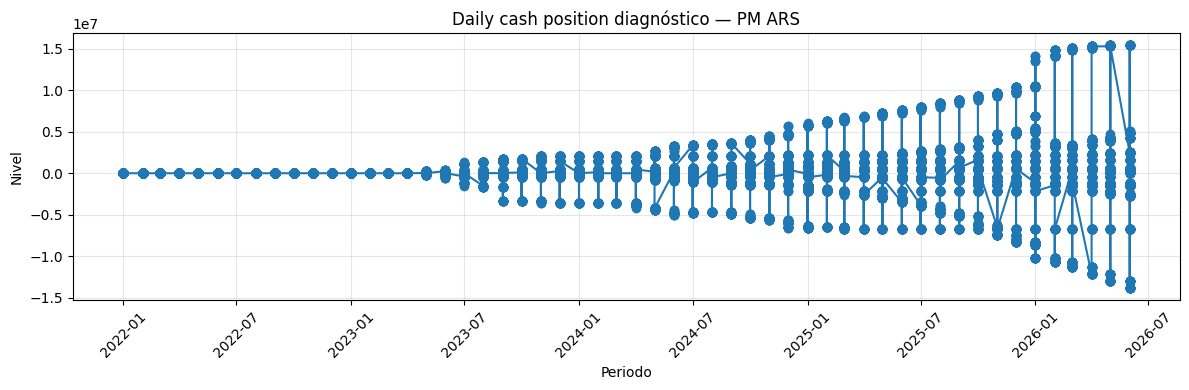

In [35]:
plot_level_ts(
    level_ts,
    source_artifact="daily_cash_position",
    currency="ARS",
    boxes=["Property Management"],
    title="Daily cash position diagnóstico — PM ARS"
)

## 5. FB / Family Business annual drain audit

Esta sección desambigua la hipótesis A/B:

- A: el drenaje está observado como `DIST.DRAWS.PERSONAL` / `personal_expense`.
- B: está observado, pero el overview no lo muestra por Box/scope.

Acá no asumimos que `FB-related` equivale a `Box = Family Business`.  
Agregamos `mask_reason` para distinguir si la fila matchea por Box, payer, receiver, actor o counterparty.


In [36]:
if flow_norm.empty:
    fb_audit = pd.DataFrame()
    fb_summary = pd.DataFrame()
else:
    fb_mask = fb_related_mask(flow_norm)
    fb_audit = flow_norm[fb_mask].copy()
    if not fb_audit.empty:
        fb_audit["mask_reason"] = fb_audit.apply(mask_reason_fb, axis=1)

    fb_summary = (
        fb_audit
        .groupby([
            "year", "Currency_norm", "Box_norm", "semantic_bucket_norm",
            "semantic_subbucket_norm", "cash_path_norm", "mask_reason",
            "payer_norm", "receiver_norm", "actor_norm", "counterparty_norm",
        ], dropna=False)
        .agg(
            amount_in=("amount_in_norm", "sum"),
            amount_out=("amount_out_norm", "sum"),
            net_amount=("net_amount_norm", "sum"),
            amount_abs=("amount_abs_norm", "sum"),
            n_rows=("net_amount_norm", "size"),
        )
        .reset_index()
        .sort_values(["year", "Currency_norm", "amount_abs"], ascending=[True, True, False])
    )

display(fb_summary.head(200))
export_table(fb_audit, repo_root, "cash_fb_related_rows_audit.csv")
export_table(fb_summary, repo_root, "cash_fb_related_grouped_audit.csv")


,year,Currency_norm,Box_norm,semantic_bucket_norm,semantic_subbucket_norm,cash_path_norm,mask_reason,payer_norm,receiver_norm,actor_norm,counterparty_norm,amount_in,amount_out,net_amount,amount_abs,n_rows
1,2022,ARS,Family Business,operating_revenue,rent,Cobros:Renta,"box_match,receiver_match,actor_match",Inq,FB,Family Business,Inq,4948804.0,0.0,4948804.0,4948804.0,46
0,2022,ARS,Family Business,family_withdrawal_candidate,personal_expense,Transfer:Gasto,"box_match,payer_match,actor_match",FB,Gasto,Family Business,Gasto,0.0,4361538.0,-4361538.0,4361538.0,12
5,2022,ARS,Family Business,property_opex,taxes,Pagos:Impuestos,"box_match,payer_match,actor_match",FB,Impuestos,Family Business,Impuestos,0.0,227940.0,-227940.0,227940.0,9
3,2022,ARS,Family Business,property_opex,maintenance,Pagos:Mantenimiento,"box_match,payer_match,actor_match",FB,Costos,Family Business,Costos,0.0,215900.0,-215900.0,215900.0,6
4,2022,ARS,Family Business,property_opex,services,Pagos:Servicio,"box_match,payer_match,actor_match",FB,Servicios,Family Business,Servicios,0.0,105726.0,-105726.0,105726.0,5
2,2022,ARS,Family Business,property_opex,legal,Pagos:Legal,"box_match,payer_match,actor_match",FB,Costos,Family Business,Costos,0.0,37700.0,-37700.0,37700.0,4
8,2023,ARS,Family Business,operating_revenue,rent,Cobros:Renta,"box_match,receiver_match,actor_match",Inq,FB,Family Business,Inq,8781302.0,0.0,8781302.0,8781302.0,46
7,2023,ARS,Family Business,family_withdrawal_candidate,personal_expense,Transfer:Gasto,"box_match,payer_match,actor_match",FB,Gasto,Family Business,Gasto,0.0,8588545.0,-8588545.0,8588545.0,12
12,2023,ARS,Family Business,property_opex,taxes,Pagos:Impuestos,"box_match,payer_match,actor_match",FB,Impuestos,Family Business,Impuestos,0.0,66256.0,-66256.0,66256.0,2
11,2023,ARS,Family Business,property_opex,services,Pagos:Servicio,"box_match,payer_match,actor_match",FB,Servicios,Family Business,Servicios,0.0,65000.0,-65000.0,65000.0,2


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_fb_related_grouped_audit.csv')

## 6. 2024 FB focus

Esta celda produce una vista específica para 2024, porque ahí vimos el patrón fuerte:

```text
renta FB ≈ retiro/gasto FB
```

La tabla permite ver si la diferencia está en renta, contribuciones, OPEX, gasto personal, debt movement o unknown.


In [37]:
fb_2024 = fb_summary[
    fb_summary.get("year", pd.Series(dtype=str)).astype(str).eq("2024")
].copy() if not fb_summary.empty else pd.DataFrame()

display(fb_2024)

# Simple compact bridge for FB-related 2024 ARS
if not fb_2024.empty:
    fb_2024_ars = fb_2024[fb_2024["Currency_norm"].astype(str).eq("ARS")].copy()
    compact_rows = []
    for bucket in sorted(fb_2024_ars["semantic_bucket_norm"].dropna().astype(str).unique()):
        b = fb_2024_ars[fb_2024_ars["semantic_bucket_norm"].astype(str).eq(bucket)]
        compact_rows.append({
            "year": "2024",
            "Currency": "ARS",
            "semantic_bucket": bucket,
            "amount_in": b["amount_in"].sum(),
            "amount_out": b["amount_out"].sum(),
            "net_amount": b["net_amount"].sum(),
            "n_rows": b["n_rows"].sum(),
        })
    fb_2024_compact = pd.DataFrame(compact_rows).sort_values("amount_out", ascending=False)
else:
    fb_2024_compact = pd.DataFrame()

display(format_display_df(fb_2024_compact, []))
export_table(fb_2024, repo_root, "cash_fb_2024_focus_detail.csv")
export_table(fb_2024_compact, repo_root, "cash_fb_2024_focus_compact.csv")


,year,Currency_norm,Box_norm,semantic_bucket_norm,semantic_subbucket_norm,cash_path_norm,mask_reason,payer_norm,receiver_norm,actor_norm,counterparty_norm,amount_in,amount_out,net_amount,amount_abs,n_rows
14,2024,ARS,Family Business,operating_revenue,rent,Cobros:Renta,"box_match,receiver_match,actor_match",Inq,FB,Family Business,Inq,13558336.0,0.0,13558336.0,13558336.0,36
13,2024,ARS,Family Business,family_withdrawal_candidate,personal_expense,Transfer:Gasto,"box_match,payer_match,actor_match",FB,Gasto,Family Business,Gasto,0.0,13558322.0,-13558322.0,13558322.0,12
15,2024,ARS,Property Management,funding_contribution,family_or_tenant_contribution,Contribucion:Contribuciones,receiver_match,Inq,FB,Property Management,Inq,150000.0,0.0,150000.0,150000.0,3


,year,Currency,semantic_bucket,amount_in,amount_out,net_amount,n_rows
0,2024,ARS,family_withdrawal_candidate,0.0,13558322.0,-13558322.0,12
1,2024,ARS,funding_contribution,150000.0,0.0,150000.0,3
2,2024,ARS,operating_revenue,13558336.0,0.0,13558336.0,36


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_fb_2024_focus_compact.csv')

## 7. Household / PM / FB comparison

El long ledger concatena FB, PM y Household.  
Esta vista permite comparar scopes sin hacerlos equivalentes.

Lectura esperada:

- PM suele concentrar OPEX y deuda operativa.
- FB puede concentrar renta y retiros.
- Household puede registrar gastos del hogar/casa de Matías y hermanos.
- La caja validada sigue siendo otro plano distinto.


In [38]:
if annual_bridge.empty:
    scope_comparison = pd.DataFrame()
else:
    scope_comparison = annual_bridge.copy()
    scope_comparison["retained_flow_probe"] = (
        scope_comparison["operating_revenue_in"]
        + scope_comparison["funding_contribution_in"]
        - scope_comparison["property_opex_out"]
        - scope_comparison["family_withdrawal_out"]
        + scope_comparison["debt_movement_net"]
        + scope_comparison["unknown_net"]
    )
    scope_comparison = scope_comparison.sort_values(["year", "Currency_norm", "Box_norm"])

display(scope_comparison)
export_table(scope_comparison, repo_root, "cash_scope_comparison_annual.csv")


,year,Currency_norm,Box_norm,operating_revenue_in,property_opex_out,family_withdrawal_out,funding_contribution_in,debt_movement_net,unknown_net,total_amount_in,total_amount_out,net_flow,amount_abs,n_rows,retained_flow_probe
0,2022,ARS,Family Business,4948804.0,587266.00,4361538.0,0.0,0.0,0.0,4948804.00,4948804.00,0.00,9897608.00,82,0.00
1,2023,ARS,Family Business,8781302.0,192756.00,8588545.0,0.0,0.0,0.0,8781302.00,8781301.00,1.00,17562603.00,67,1.00
2,2023,ARS,Household,0.0,313468.00,0.0,0.0,0.0,0.0,294630.00,313468.00,-18838.00,608098.00,20,-313468.00
3,2023,ARS,Property Management,360000.0,1886317.00,0.0,0.0,0.0,0.0,4012537.00,1886317.00,2126220.00,5898854.00,42,-1526317.00
4,2023,USD,Property Management,0.0,0.00,0.0,0.0,-210.0,0.0,0.00,210.00,-210.00,210.00,1,-210.00
5,2024,ARS,Family Business,13558336.0,0.00,13558322.0,0.0,0.0,0.0,13558336.00,13558322.00,14.00,27116658.00,48,14.00
6,2024,ARS,Household,0.0,2101083.84,0.0,1422000.0,-1354000.0,0.0,3455083.84,3455083.84,0.00,6910167.68,53,-2033083.84
7,2024,ARS,Property Management,0.0,5965218.00,0.0,210000.0,-419243.0,0.0,5839752.00,6384461.00,-544709.00,12224213.00,100,-6174461.00
8,2024,USD,Household,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,1,0.00
9,2024,USD,Property Management,3610.0,0.00,100.0,0.0,-100.0,0.0,3610.00,2130.00,1480.00,5740.00,18,3410.00


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_scope_comparison_annual.csv')

## 8. Professional comments

Notas que deberían viajar con el reporte.


In [39]:
cash_comments = pd.DataFrame([
    {"tema": "Caja validada", "comentario": "Sin validated_cash_close/frontend-safe, la caja de cierre anual debe quedar s/d. No se debe inferir caja desde flows."},
    {"tema": "Box", "comentario": "Box se trata como órbita/scope de gobernanza, no automáticamente como caja física."},
    {"tema": "Flow bridge", "comentario": "El bridge anual por Box muestra entradas, salidas y neto observado; es útil para explicar drenaje o retención, pero no reemplaza un saldo de caja."},
    {"tema": "FB", "comentario": "Si FB muestra renta casi igual a retiros/gasto, el hallazgo es drenaje/consumo de la renta, no ausencia de datos."},
    {"tema": "Household", "comentario": "Household es un scope real del long ledger y debe analizarse separado de PM/FB."},
    {"tema": "Settlement", "comentario": "Pagos directos por inquilinos o actores pueden cancelar obligaciones sin pasar por caja validada."},
    {"tema": "Próxima notebook", "comentario": "El diagrama de flechas por actor/counterparty/cash_path es excelente, pero conviene hacerlo después de cerrar semántica fina."},
])
display(cash_comments)
export_table(cash_comments, repo_root, "cash_professional_comments.csv")


,tema,comentario
0,Caja validada,"Sin validated_cash_close/frontend-safe, la caj..."
1,Box,"Box se trata como órbita/scope de gobernanza, ..."
2,Flow bridge,"El bridge anual por Box muestra entradas, sali..."
3,FB,Si FB muestra renta casi igual a retiros/gasto...
4,Household,Household es un scope real del long ledger y d...
5,Settlement,Pagos directos por inquilinos o actores pueden...
6,Próxima notebook,El diagrama de flechas por actor/counterparty/...


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/cash_professional_comments.csv')

## 9. Export report

In [40]:
md_path = write_markdown_report(
    repo_root,
    "02_cash_and_liquidity.md",
    "02 — Cash and liquidity",
    [
        ("Scope", "Reporte anual de caja validada y flujos por Box/scope. Caja validada y flow bridge no son lo mismo."),
        ("Cash QA", cash_qa),
        ("Cash metrics inventory", cash_metrics),
        ("Validated cash from annual metrics", cash_levels_from_metrics),
        ("Annual Box flow bridge", annual_bridge_wide),
        ("FB related grouped audit", fb_summary.head(200) if not fb_summary.empty else fb_summary),
        ("2024 FB compact", fb_2024_compact),
        ("Scope comparison", scope_comparison),
        ("Professional comments", cash_comments),
    ],
)
html_path = write_html_report(
    repo_root,
    "02_cash_and_liquidity.html",
    "02 — Cash and liquidity",
    [
        ("Scope", "Reporte anual de caja validada y flujos por Box/scope. Caja validada y flow bridge no son lo mismo."),
        ("Cash QA", cash_qa),
        ("Cash metrics inventory", cash_metrics),
        ("Validated cash from annual metrics", cash_levels_from_metrics),
        ("Annual Box flow bridge", annual_bridge_wide),
        ("FB related grouped audit", fb_summary.head(200) if not fb_summary.empty else fb_summary),
        ("2024 FB compact", fb_2024_compact),
        ("Scope comparison", scope_comparison),
        ("Professional comments", cash_comments),
    ],
)
print("markdown:", md_path.relative_to(repo_root))
print("html:", html_path.relative_to(repo_root))


markdown: out/professional_pack/latest/markdown/02_cash_and_liquidity.md
html: out/professional_pack/latest/html/02_cash_and_liquidity.html


## 10. Backlog: flow network diagram

No se implementa acá para no mezclar objetivos, pero queda capturado:

```text
06_flow_network_diagram.ipynb
```

Idea:

- nodos = actores / scopes / counterparties;
- flechas = payer → receiver;
- ancho = amount_abs;
- color = semantic_bucket;
- facet = year / Currency;
- filtros = Box, cash_path, semantic_subbucket.

Esto será ideal para mostrar visualmente el drenaje de FB, pagos directos, contribuciones y settlements.
